# NOAA Global Hourly: Glasgow Airport

This example downloads observations for Glasgow Airport (WMO station `03140099999`, ICAO `EGPF`) from NOAA's public Global Hourly API, cleans packed weather fields, and plots temperature and wind speed.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'python_code'))

from noaa_global_hourly import (
    clean_global_hourly,
    fetch_global_hourly,
    plot_weather,
)

In [2]:
station = '03140099999'
station_name = 'Glasgow Airport (EGPF)'
start_date = '2024-01-01'
end_date = '2024-01-03'

raw = fetch_global_hourly(station, start_date, end_date)
if raw.empty:
    raise RuntimeError('NOAA returned no records. Check the station ID or date range.')

print(f'Downloaded {len(raw):,} records with {len(raw.columns)} fields.')
raw.head(3)

Downloaded 143 records with 27 fields.


,CIG,REPORT_TYPE,VIS,QUALITY_CONTROL,STATION,LONGITUDE,ELEVATION,WND,NAME,DATE,...,REM,MA1,LATITUDE,CALL_SIGN,GA2,GA3,AW1,MW1,AW2,ED1
0,"00914,1,C,N",FM-15,"009999,1,9,9",V020,03140099999,-4.433056,7.92,"250,1,N,0010,1","GLASGOW, UK",2024-01-01T00:20:00,...,MET056METAR EGPF 010020Z AUTO 25002KT 9999 OVC...,"09870,1,99999,9",55.871944,99999,NaN,NaN,NaN,NaN,NaN,NaN
1,"00914,1,C,N",FM-15,"009999,1,9,9",V020,03140099999,-4.433056,7.92,"999,9,V,0005,1","GLASGOW, UK",2024-01-01T00:50:00,...,MET056METAR EGPF 010050Z AUTO VRB01KT 9999 OVC...,"09880,1,99999,9",55.871944,99999,NaN,NaN,NaN,NaN,NaN,NaN
2,"00884,1,C,N",FM-15,"009999,1,9,9",V020,03140099999,-4.433056,7.92,"190,1,N,0010,1","GLASGOW, UK",2024-01-01T01:20:00,...,MET063METAR EGPF 010120Z AUTO 19002KT 9999 BKN...,"09880,1,99999,9",55.871944,99999,"08,1,+01006,1,99,9",NaN,NaN,NaN,NaN,NaN


In [3]:
cleaned = clean_global_hourly(raw)

summary = cleaned[['DATE', 'temperature_c', 'dew_point_c', 'wind_direction_deg', 'wind_speed_mps']]
summary.head(10)

,DATE,temperature_c,dew_point_c,wind_direction_deg,wind_speed_mps
0,2024-01-01 00:20:00+00:00,3.0,2.0,250.0,1.0
1,2024-01-01 00:50:00+00:00,3.0,2.0,NaN,0.5
2,2024-01-01 01:20:00+00:00,3.0,2.0,190.0,1.0
3,2024-01-01 01:50:00+00:00,3.0,2.0,220.0,1.5
4,2024-01-01 02:20:00+00:00,3.0,2.0,230.0,2.6
5,2024-01-01 02:50:00+00:00,3.0,3.0,230.0,1.5
6,2024-01-01 03:20:00+00:00,3.0,3.0,240.0,1.5
7,2024-01-01 03:50:00+00:00,4.0,3.0,240.0,2.1
8,2024-01-01 04:20:00+00:00,4.0,4.0,270.0,3.6
9,2024-01-01 04:50:00+00:00,5.0,4.0,280.0,3.6


       temperature_c  dew_point_c  wind_speed_mps
count     143.000000   143.000000      143.000000
mean        5.356643     4.174825        2.860140
std         1.840107     1.835927        1.841927
min         2.000000     1.000000        0.500000
25%         4.000000     3.000000        1.500000
50%         5.000000     5.000000        2.100000
75%         6.500000     6.000000        4.100000
max         9.000000     7.000000        8.200000


(<Figure size 1200x700 with 2 Axes>,
 (<Axes: title={'center': 'Glasgow Airport (EGPF): NOAA Global Hourly'}, ylabel='Temperature (C)'>,
  <Axes: xlabel='Observation time (UTC)', ylabel='Wind speed (m/s)'>))

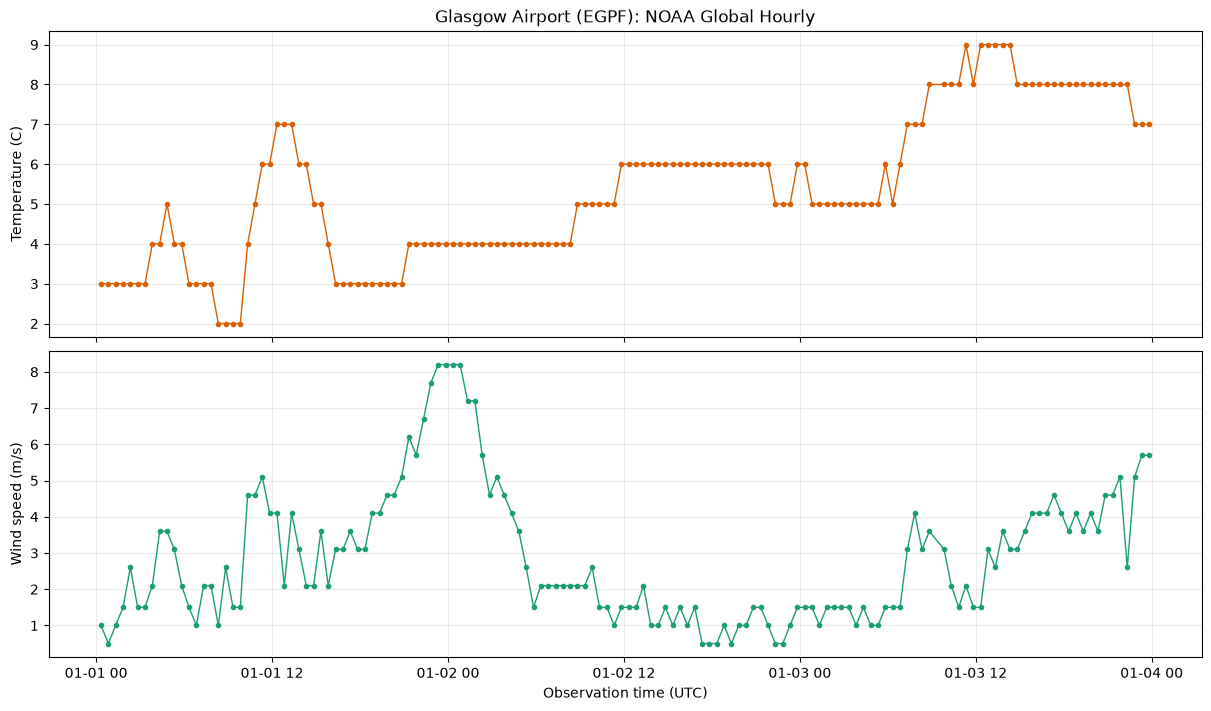

In [4]:
print(cleaned[['temperature_c', 'dew_point_c', 'wind_speed_mps']].describe())
plot_weather(cleaned, station_name=station_name)